In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from bootcampviztools import pinta_distribucion_categoricas, plot_categorical_relationship_fin, plot_categorical_numerical_relationship, tricategorical_analysis

In [2]:
df_adopciones = pd.read_csv("../data/Raw/pet_adoption_data.csv")
df_adopciones

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
0,500,Bird,Parakeet,131,Orange,Large,5.039768,1,0,27,140,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.086727,0,0,8,235,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.076286,0,0,85,385,0,0
3,503,Bird,Parakeet,97,White,Small,3.339423,0,0,61,217,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.498100,0,0,28,14,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2002,2502,Dog,Poodle,72,Orange,Small,27.039045,1,0,66,26,1,1
2003,2503,Rabbit,Rabbit,124,Brown,Small,4.726954,1,1,59,150,0,0
2004,2504,Rabbit,Rabbit,113,Orange,Small,1.758592,1,0,68,302,0,0
2005,2505,Dog,Labrador,12,Gray,Large,20.961592,1,0,59,478,0,0


In [3]:
# Transformación de edad de meses a años:

df_adopciones["AgeYears"] = round(df_adopciones["AgeMonths"]/12, 2)

In [4]:
df_adopciones = df_adopciones.drop(columns = ["AgeMonths"], axis = 1)

***

### Visualización de variable target

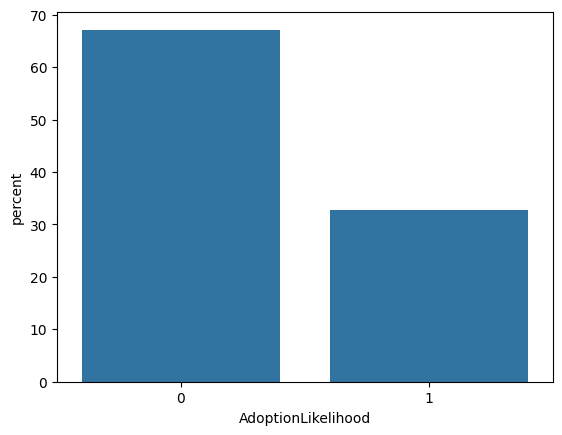

In [5]:
sns.countplot(data = df_adopciones, x = "AdoptionLikelihood", stat = "percent")
plt.show();

- Variable binaria
- No adoptados --> 0 
- Adoptados --> 1

Distribución: Se observa una mayor proporción de animales no adoptados frente a los que han sido adoptados (desbalanceada)

***

### Correlación de variables categóricas con variable target

Hipótesis H0 -> No están relacionadas entre sí  

Hipótesis H1 -> Están relacionadas

Para todas las variables!!!

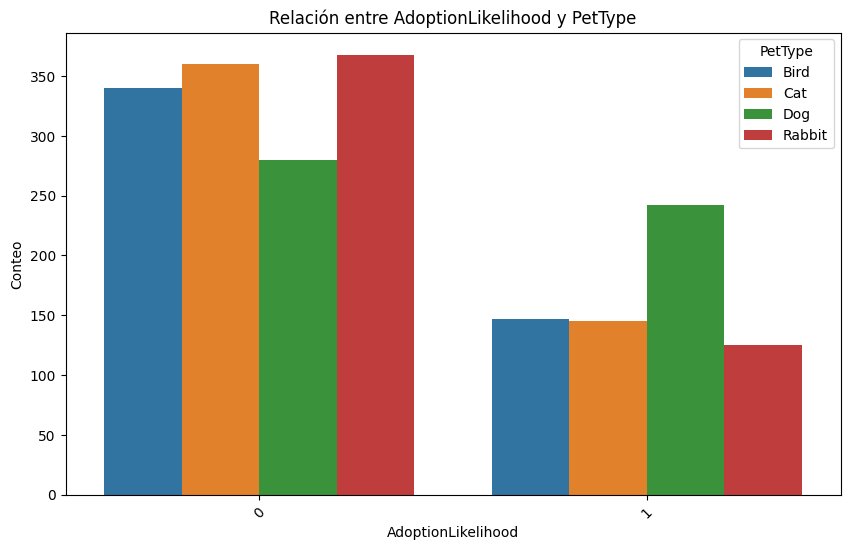

In [6]:
plot_categorical_relationship_fin(df_adopciones, "AdoptionLikelihood", "PetType")

In [7]:
tabla_contingencia = pd.crosstab(df_adopciones['AdoptionLikelihood'], df_adopciones['PetType'])

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2, "\n")
print("P-Value:", p, "\n")
print("Grados de Libertad:", dof, "\n")
print("Tabla de Frecuencias Esperadas:\n", expected)


Valor Chi-Cuadrado: 61.24812856294096 

P-Value: 3.1808930207055546e-13 

Grados de Libertad: 3 

Tabla de Frecuencias Esperadas:
 [[327.09317389 339.18285999 350.60089686 331.12306926]
 [159.90682611 165.81714001 171.39910314 161.87693074]]


p-value <<<<< 0.05, se acepta H1 --> Relación estadísticamente significativa

***

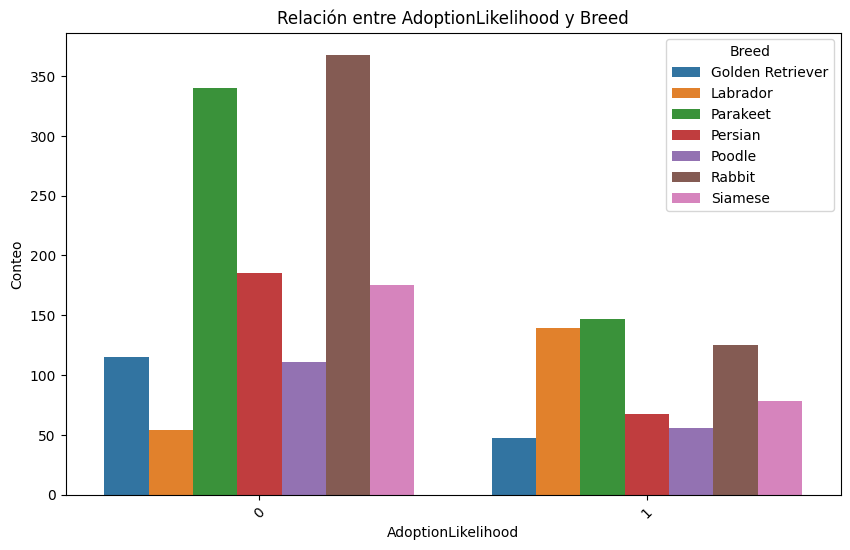

In [8]:
plot_categorical_relationship_fin(df_adopciones, "AdoptionLikelihood", "Breed")

In [9]:
tabla_contingencia = pd.crosstab(df_adopciones['AdoptionLikelihood'], df_adopciones['Breed'])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2, "\n")
print("P-Value:", p, "\n")
print("Grados de Libertad:", dof, "\n")
print("Tabla de Frecuencias Esperadas:\n", expected)


Valor Chi-Cuadrado: 154.4696068447621 

P-Value: 8.773886416003854e-31 

Grados de Libertad: 6 

Tabla de Frecuencias Esperadas:
 [[108.80717489 129.62830095 327.09317389 169.25560538 112.16542103
  331.12306926 169.92725461]
 [ 53.19282511  63.37169905 159.90682611  82.74439462  54.83457897
  161.87693074  83.07274539]]


p-value <<<<< 0.05, se acepta H1 --> Relación estadísticamente significativa

***

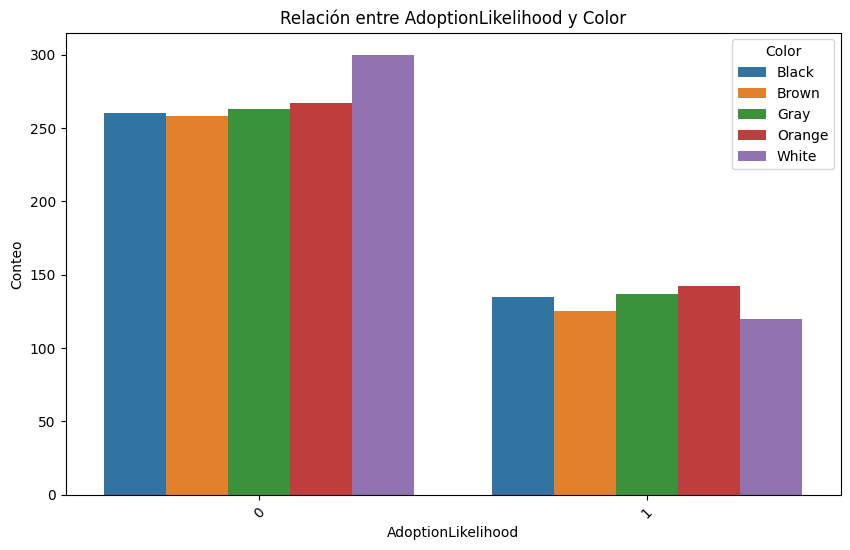

In [10]:
plot_categorical_relationship_fin(df_adopciones, "AdoptionLikelihood", "Color")

In [11]:
tabla_contingencia = pd.crosstab(df_adopciones['AdoptionLikelihood'], df_adopciones['Color'])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2, "\n")
print("P-Value:", p, "\n")
print("Grados de Libertad:", dof, "\n")
print("Tabla de Frecuencias Esperadas:\n", expected)


Valor Chi-Cuadrado: 4.812689904113481 

P-Value: 0.3070621535939598 

Grados de Libertad: 4 

Tabla de Frecuencias Esperadas:
 [[265.30144494 257.24165421 268.65969108 274.70453413 282.09267564]
 [129.69855506 125.75834579 131.34030892 134.29546587 137.90732436]]


Las diferencias entre colores dentro de cada categoría de adopción no parecen muy grandes, y eso suele indicar que no hay una relación fuerte entre el color del pelaje y la probabilidad de adopción. 

- Patrones parecidos entre adoptados y no adoptados
- No hay un color que destaque como mucho más adoptado o mucho menos adoptado
- Se observa que las columnas de color de pelaje, muestran el número de individuos de cada columna, no la adopción.

Queda confirmado por el p-value obtenido (p-value >>>>>> 0.05, no se puede rechazar H0)


***

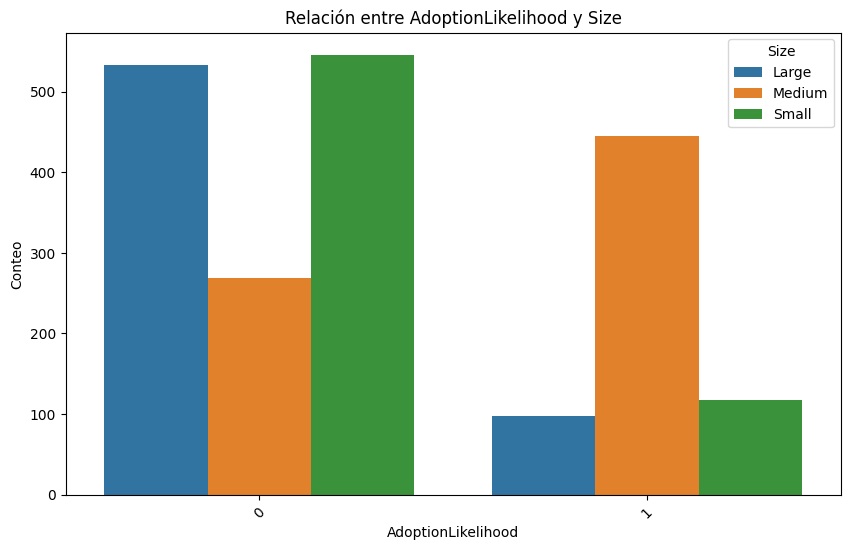

In [12]:
plot_categorical_relationship_fin(df_adopciones, "AdoptionLikelihood", "Size")

In [13]:
tabla_contingencia = pd.crosstab(df_adopciones['AdoptionLikelihood'], df_adopciones['Size'])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2, "\n")
print("P-Value:", p, "\n")
print("Grados de Libertad:", dof, "\n")
print("Tabla de Frecuencias Esperadas:\n", expected)


Valor Chi-Cuadrado: 437.7721611993275 

P-Value: 8.68926475706044e-96 

Grados de Libertad: 2 

Tabla de Frecuencias Esperadas:
 [[423.13901345 479.55754858 445.30343797]
 [206.86098655 234.44245142 217.69656203]]


p-value <<<<< 0.05, se acepta H1 --> Relación estadísticamente significativa

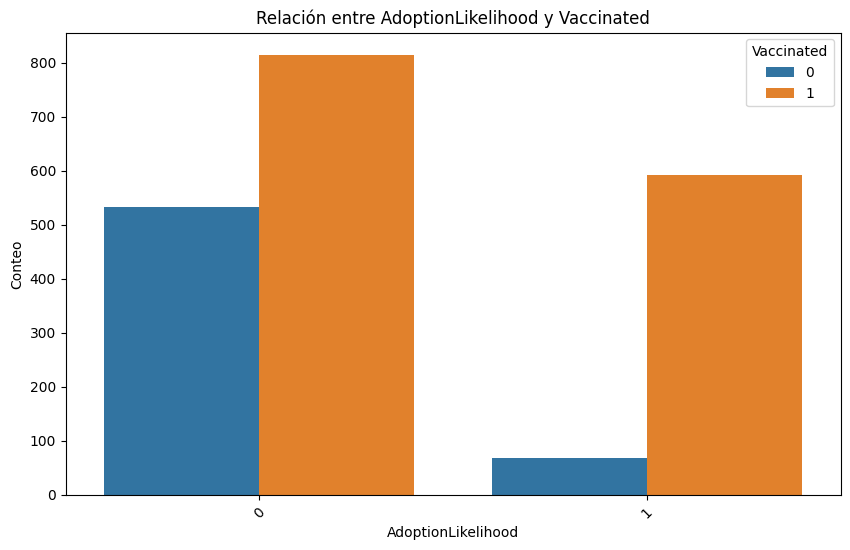

In [14]:
plot_categorical_relationship_fin(df_adopciones, "AdoptionLikelihood", "Vaccinated")

In [15]:
tabla_contingencia = pd.crosstab(df_adopciones['AdoptionLikelihood'], df_adopciones['Vaccinated'])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2, "\n")
print("P-Value:", p, "\n")
print("Grados de Libertad:", dof, "\n")
print("Tabla de Frecuencias Esperadas:\n", expected)


Valor Chi-Cuadrado: 180.81363508525638 

P-Value: 3.219385139274554e-41 

Grados de Libertad: 1 

Tabla de Frecuencias Esperadas:
 [[402.98953662 945.01046338]
 [197.01046338 461.98953662]]


En este caso, también se está realizando un conteo de los animales no adoptados (vacunados o no) y los no adoptados (vacunados o no):

- En no adoptados hay muchos más vacunados que no vacunados (lo cual no tiene mucho sentido)
- En adoptados, hay muchos más vacunados que no

Sin embargo, al realizar el test de Chi2, es necesario aceptar H1, dado que el p-valor tiene un valor muy inferior a 0.05. De modo que hay relación estadísticamente significativa entre ambas variables.

***

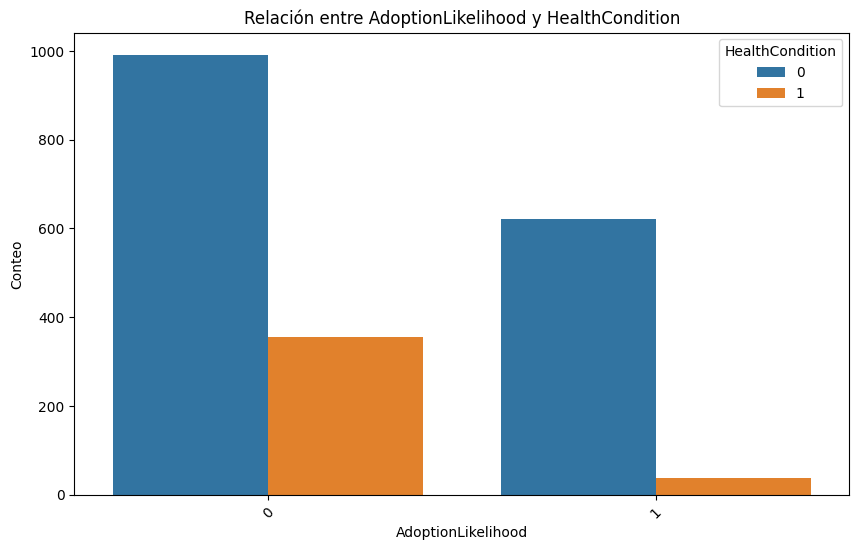

In [16]:
plot_categorical_relationship_fin(df_adopciones, "AdoptionLikelihood", "HealthCondition")

In [17]:
tabla_contingencia = pd.crosstab(df_adopciones["AdoptionLikelihood"], df_adopciones["HealthCondition"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2, "\n")
print("P-Value:", p, "\n")
print("Grados de Libertad:", dof, "\n")
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 118.24403198228453 

P-Value: 1.5331578569746707e-27 

Grados de Libertad: 1 

Tabla de Frecuencias Esperadas:
 [[1083.37020429  264.62979571]
 [ 529.62979571  129.37020429]]


p-value <<<<< 0.05, se acepta H1 --> Relación estadísticamente significativa

***

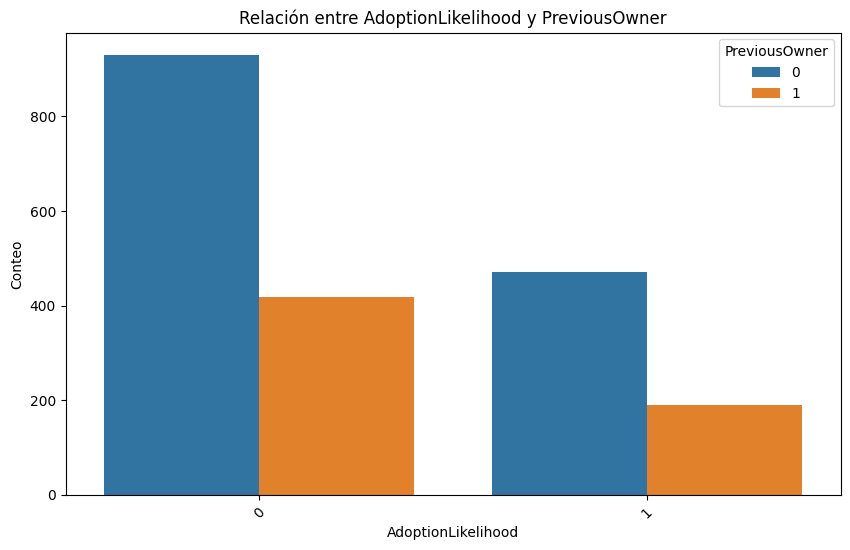

In [18]:
plot_categorical_relationship_fin(df_adopciones, "AdoptionLikelihood", "PreviousOwner")

In [19]:
tabla_contingencia = pd.crosstab(df_adopciones["AdoptionLikelihood"], df_adopciones["PreviousOwner"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2, "\n")
print("P-Value:", p, "\n")
print("Grados de Libertad:", dof, "\n")
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 0.9634402088047009 

P-Value: 0.32632163897757926 

Grados de Libertad: 1 

Tabla de Frecuencias Esperadas:
 [[940.98056801 407.01943199]
 [460.01943199 198.98056801]]


- Patrones parecidos entre adoptados y no adoptados
- Sin dueño previo tiene muchos más individuos tanto en no adoptados, como en adoptados
- Se observa que las columnas de dueño previo, muestran el número de individuos de cada columna, no la adopción.

Queda confirmado por el p-value obtenido (p-value >>>>>> 0.05, no se puede rechazar H0)


***

##### Categóricas que permanecen:

| Variable | Descripción | 
| -------- | ----------- | 
| PetType  | Tipo de animal 
| Breed    | Raza 
| Size | Tamaño del animal 
| Vaccinated | Vacunación (1) o no (0) |
| HealthCondition | Sano (0) o con medicación (1) |

### Correlación de las variables categóricas entre sí

Respuesta Bird:


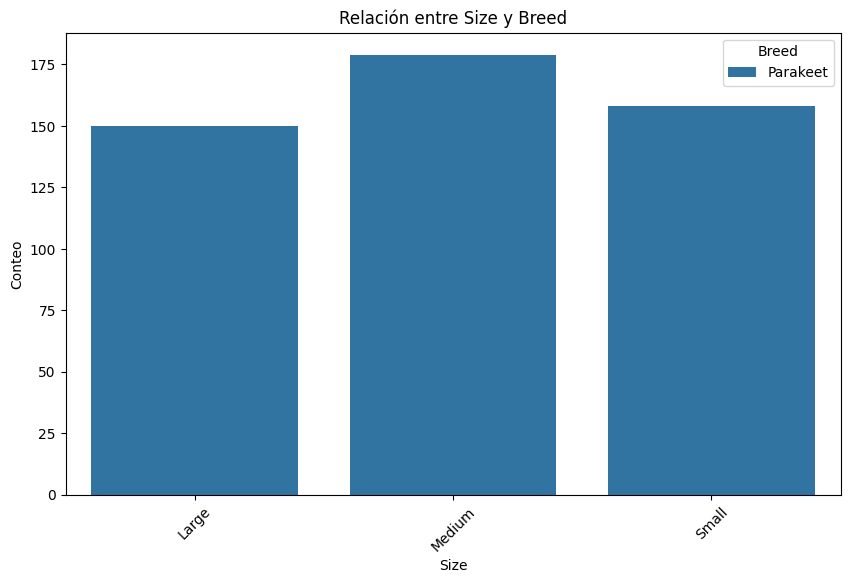

Respuesta Rabbit:


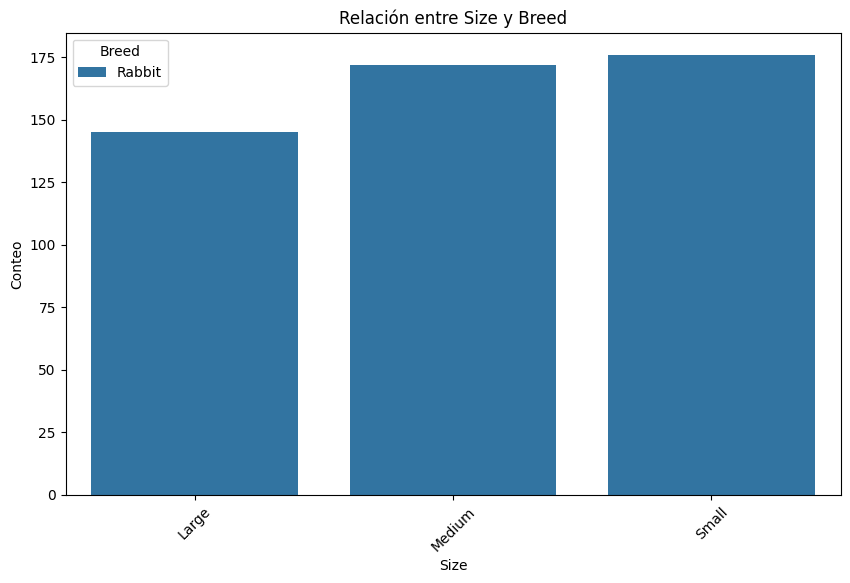

Respuesta Dog:


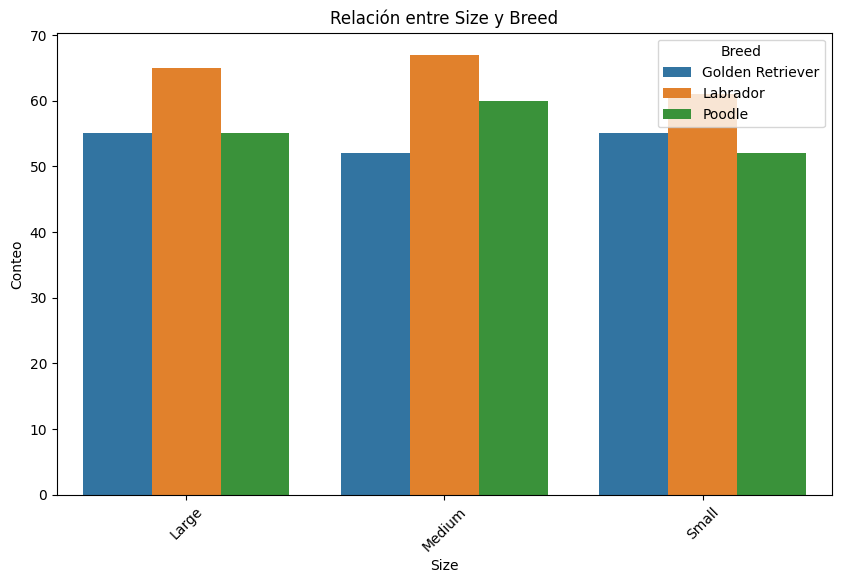

Respuesta Cat:


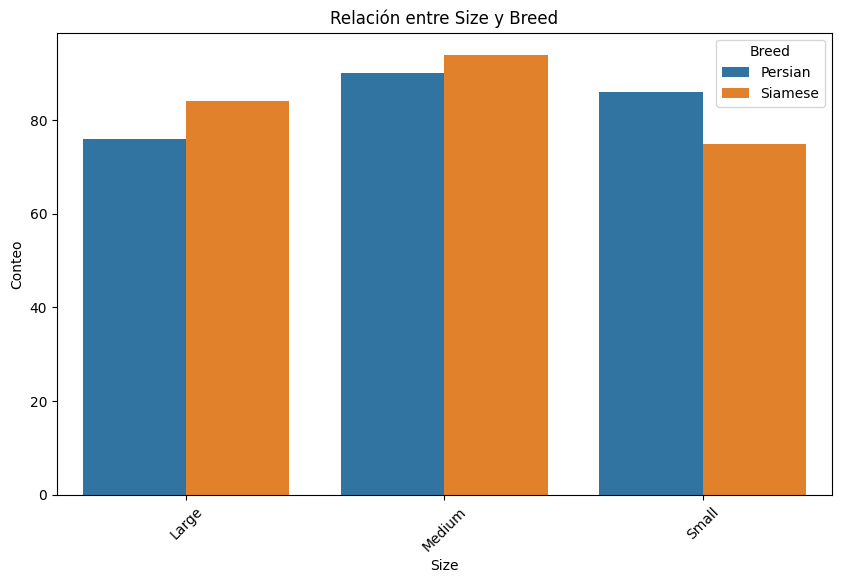

In [50]:
tricategorical_analysis(df_adopciones, "PetType", ["Breed", "Size"])

In [52]:
tabla_contingencia = pd.crosstab(df_adopciones["Breed"], df_adopciones["Size"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2, "\n")
print("P-Value:", p, "\n")
print("Grados de Libertad:", dof, "\n")
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 5.29830225935125 

P-Value: 0.947266157805247 

Grados de Libertad: 12 

Tabla de Frecuencias Esperadas:
 [[ 50.85201794  57.632287    53.51569507]
 [ 60.58295964  68.66068759  63.75635277]
 [152.86995516 173.25261584 160.877429  ]
 [ 79.10313901  89.65022422  83.24663677]
 [ 52.42152466  59.41106129  55.16741405]
 [154.75336323 175.38714499 162.85949178]
 [ 79.41704036  90.00597907  83.57698057]]


Desde mi punto de vista, estas tres variables están muy poco correladas entre sí. Siguen patrones muy similares y ningún color destaca por encima de otro. Variables independientes entre sí. Confirmado por el p-value

Respuesta Bird:


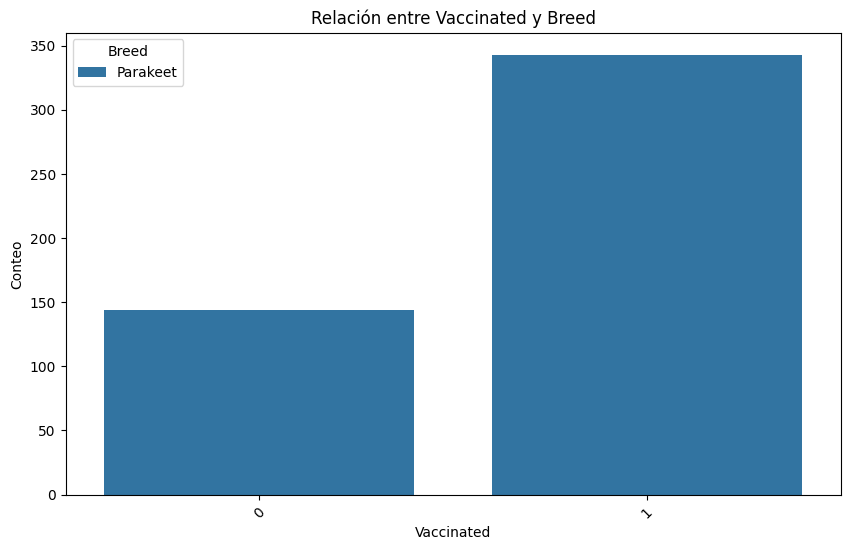

Respuesta Rabbit:


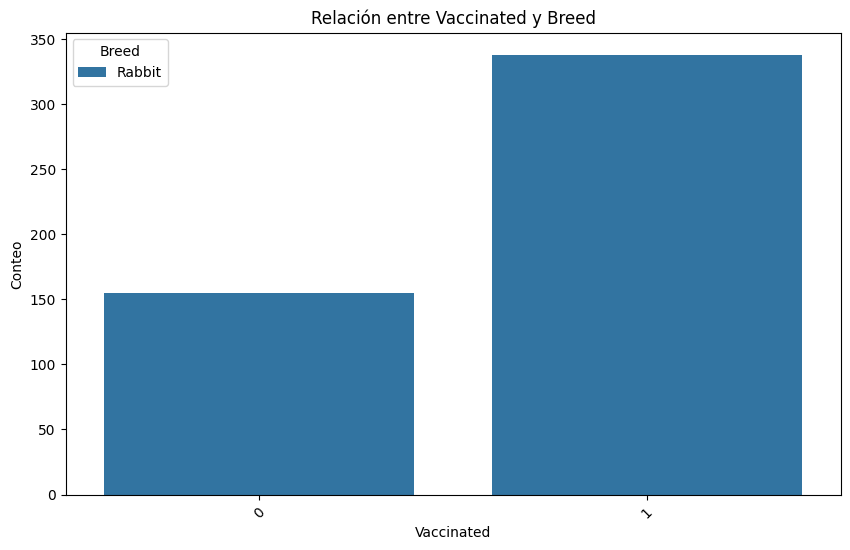

Respuesta Dog:


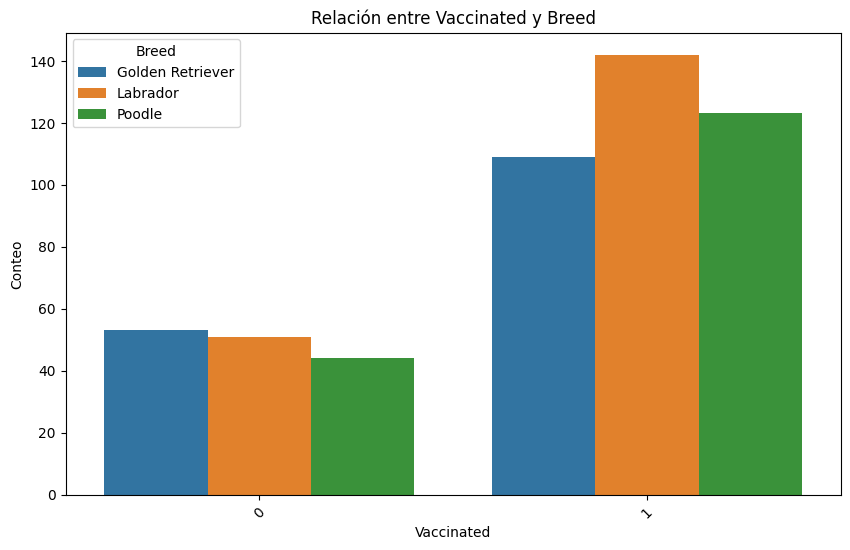

Respuesta Cat:


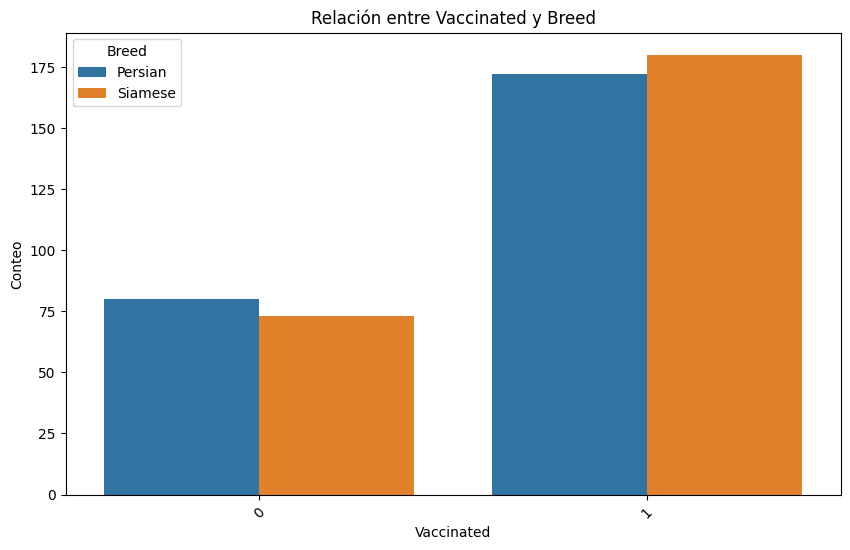

In [51]:
tricategorical_analysis(df_adopciones, "PetType", ["Breed", "Vaccinated"])

In [53]:
tabla_contingencia = pd.crosstab(df_adopciones["Breed"], df_adopciones["Vaccinated"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2, "\n")
print("P-Value:", p, "\n")
print("Grados de Libertad:", dof, "\n")
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 3.856184806964059 

P-Value: 0.6961311487904578 

Grados de Libertad: 6 

Tabla de Frecuencias Esperadas:
 [[ 48.43049327 113.56950673]
 [ 57.6980568  135.3019432 ]
 [145.59043348 341.40956652]
 [ 75.33632287 176.66367713]
 [ 49.92526158 117.07473842]
 [147.38415546 345.61584454]
 [ 75.63527653 177.36472347]]


Desde mi punto de vista, no veo que estén correladas entre sí. Yo creo que están vacunadas o no vacunadas, pero no que haya correlación entre la raza y la vacunación. Confirmado por p-value

Respuesta Bird:


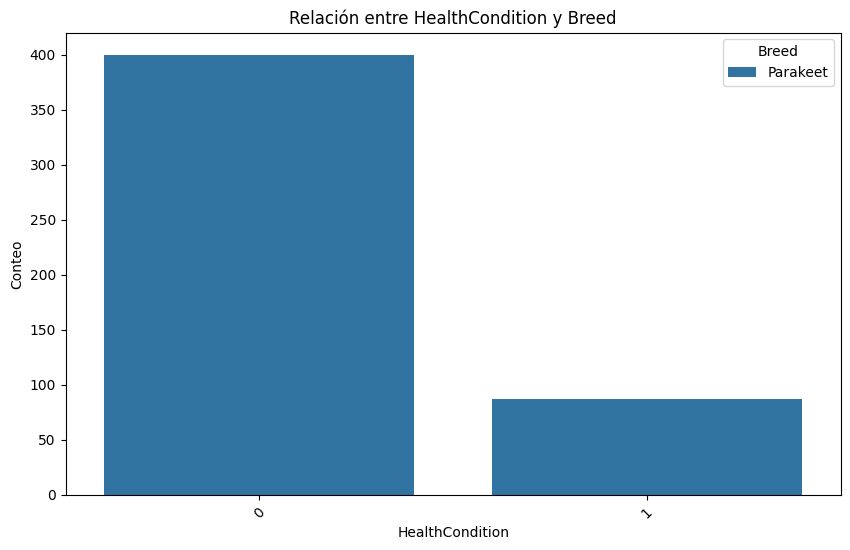

Respuesta Rabbit:


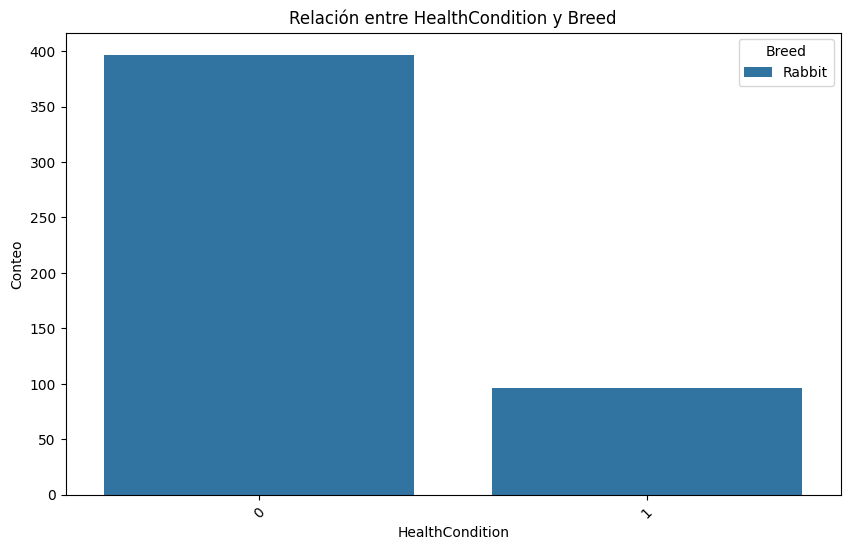

Respuesta Dog:


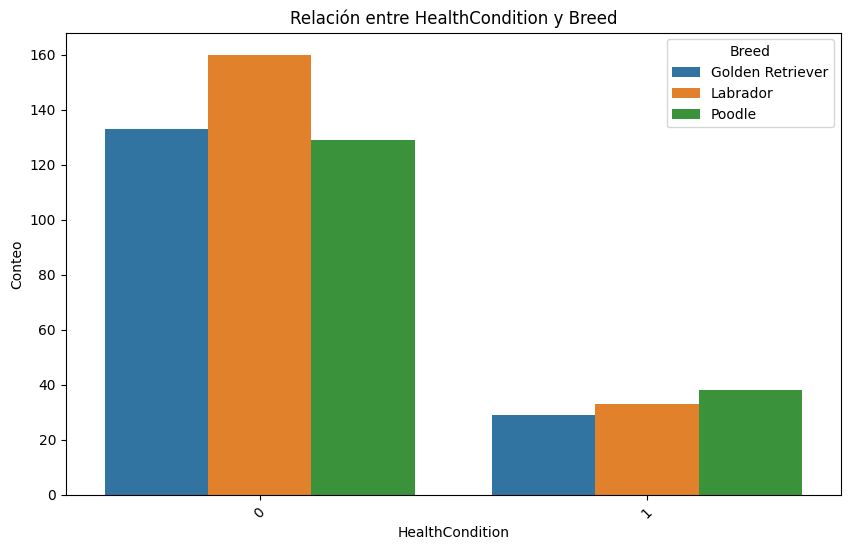

Respuesta Cat:


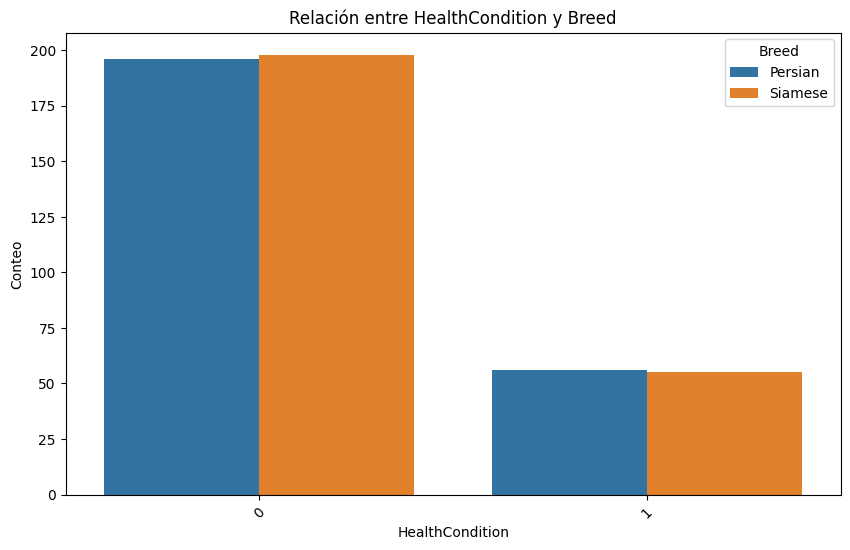

In [54]:
tricategorical_analysis(df_adopciones, "PetType", ["Breed", "HealthCondition"])

In [55]:
tabla_contingencia = pd.crosstab(df_adopciones["Breed"], df_adopciones["HealthCondition"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2, "\n")
print("P-Value:", p, "\n")
print("Grados de Libertad:", dof, "\n")
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 4.880645971032373 

P-Value: 0.5592099521436007 

Grados de Libertad: 6 

Tabla de Frecuencias Esperadas:
 [[130.19730942  31.80269058]
 [155.11160937  37.88839063]
 [391.39561535  95.60438465]
 [202.52914798  49.47085202]
 [134.21574489  32.78425511]
 [396.21773792  96.78226208]
 [203.33283508  49.66716492]]


Variable igual que la anterior: Son independientes entre sí. Yo creo que están sanos o no, pero no que haya correlación entre la raza y la vacunación. Confirmado por p-value

Respuesta Bird:


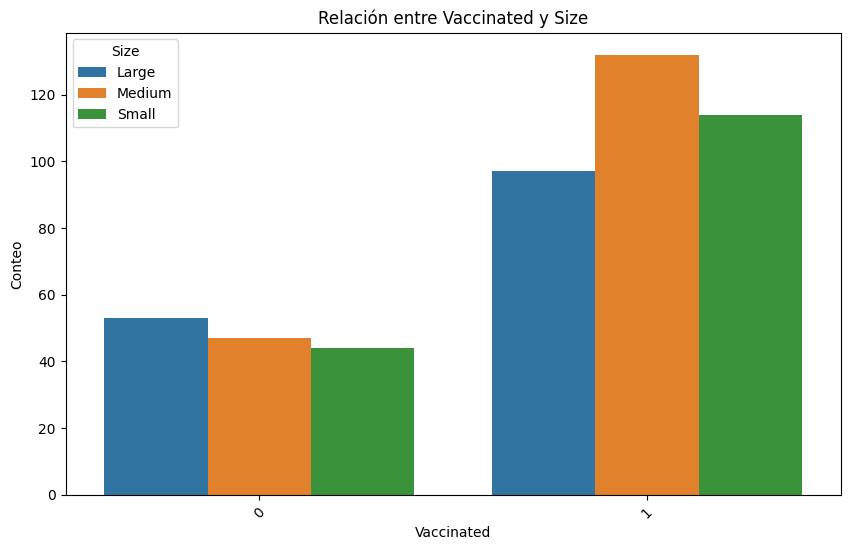

Respuesta Rabbit:


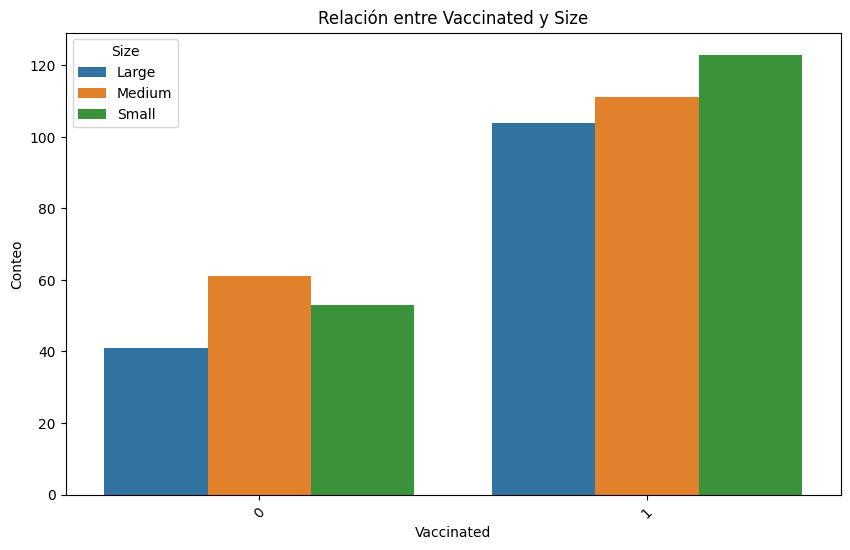

Respuesta Dog:


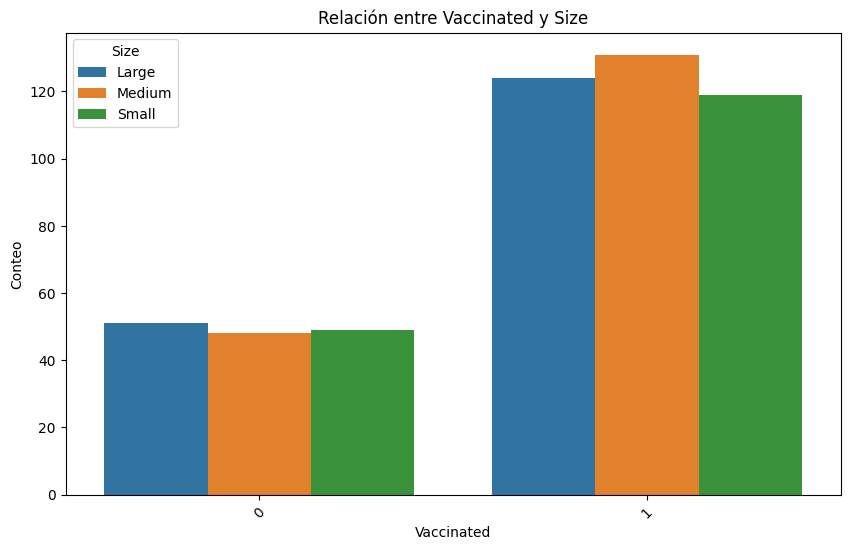

Respuesta Cat:


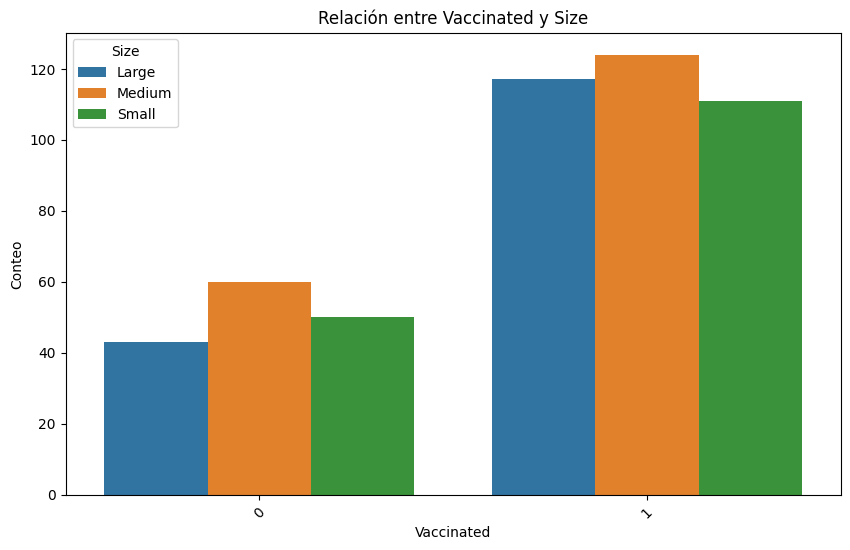

In [56]:
tricategorical_analysis(df_adopciones, "PetType", ["Size", "Vaccinated"])

In [57]:
tabla_contingencia = pd.crosstab(df_adopciones["Size"], df_adopciones["Vaccinated"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2, "\n")
print("P-Value:", p, "\n")
print("Grados de Libertad:", dof, "\n")
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 0.07926588499923491 

P-Value: 0.9611421688543335 

Grados de Libertad: 2 

Tabla de Frecuencias Esperadas:
 [[188.34080717 441.65919283]
 [213.4529148  500.5470852 ]
 [198.20627803 464.79372197]]


Variables independientes, confirmado por p-valor

Respuesta Bird:


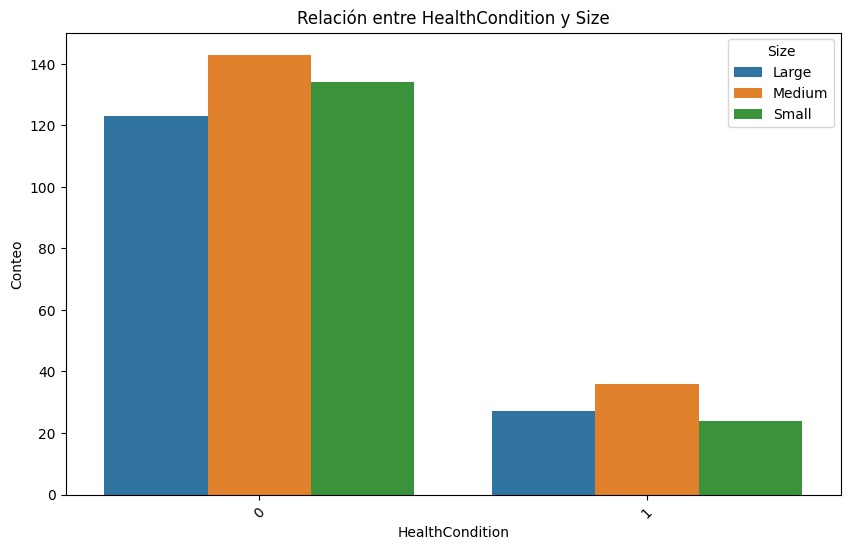

Respuesta Rabbit:


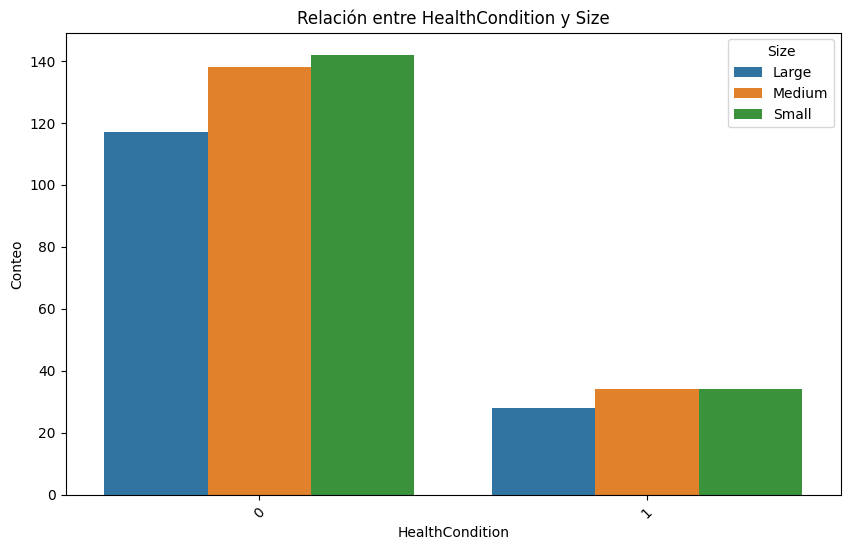

Respuesta Dog:


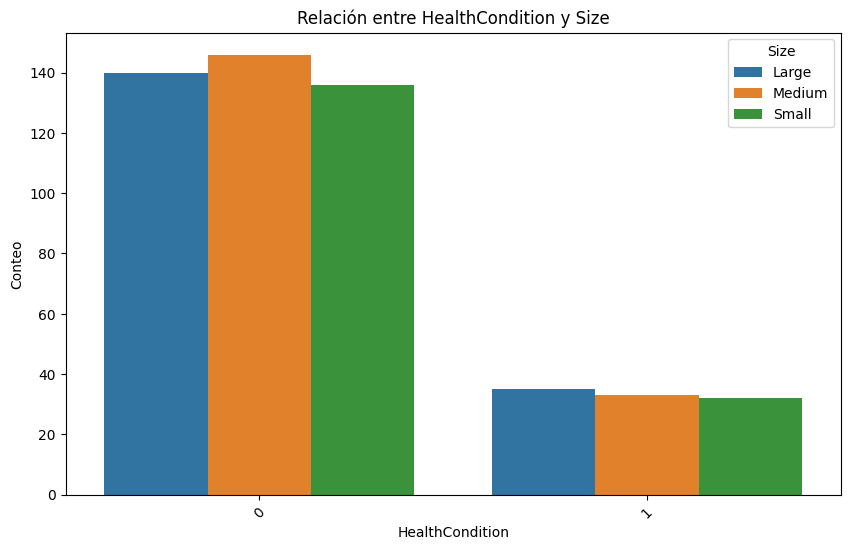

Respuesta Cat:


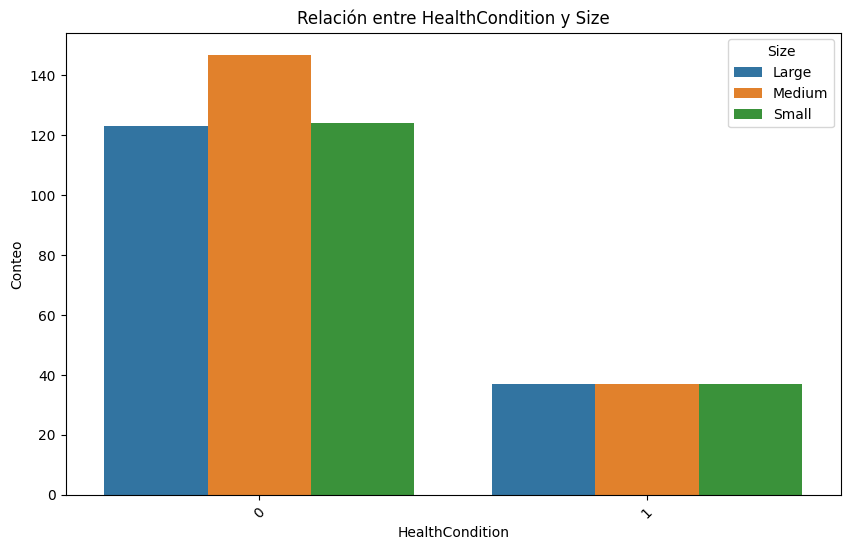

In [58]:
tricategorical_analysis(df_adopciones, "PetType", ["Size", "HealthCondition"])

In [59]:
tabla_contingencia = pd.crosstab(df_adopciones["Size"], df_adopciones["HealthCondition"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2, "\n")
print("P-Value:", p, "\n")
print("Grados de Libertad:", dof, "\n")
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 0.20651887970417354 

P-Value: 0.9018929561509763 

Grados de Libertad: 2 

Tabla de Frecuencias Esperadas:
 [[506.32286996 123.67713004]
 [573.83258595 140.16741405]
 [532.8445441  130.1554559 ]]


Igual que en las variables anteriores, se confirma independencia de las variables. Confirmado por p-value

Respuesta Bird:


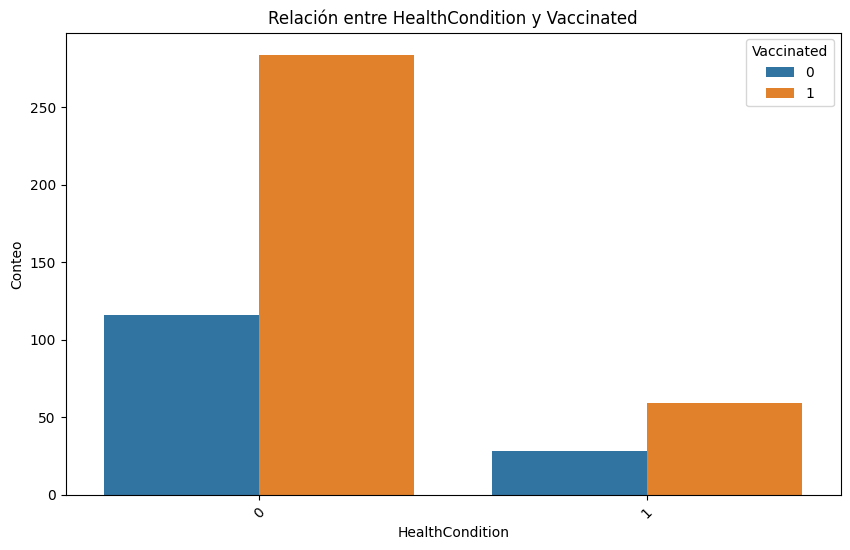

Respuesta Rabbit:


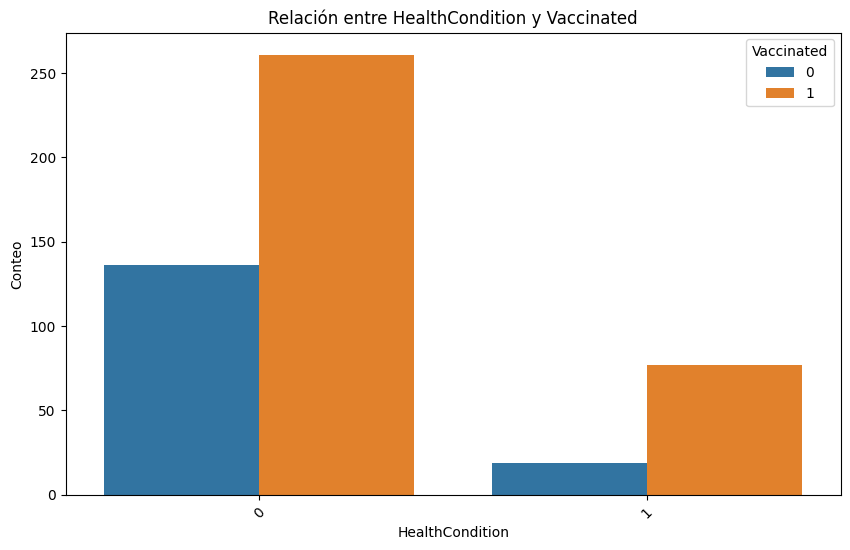

Respuesta Dog:


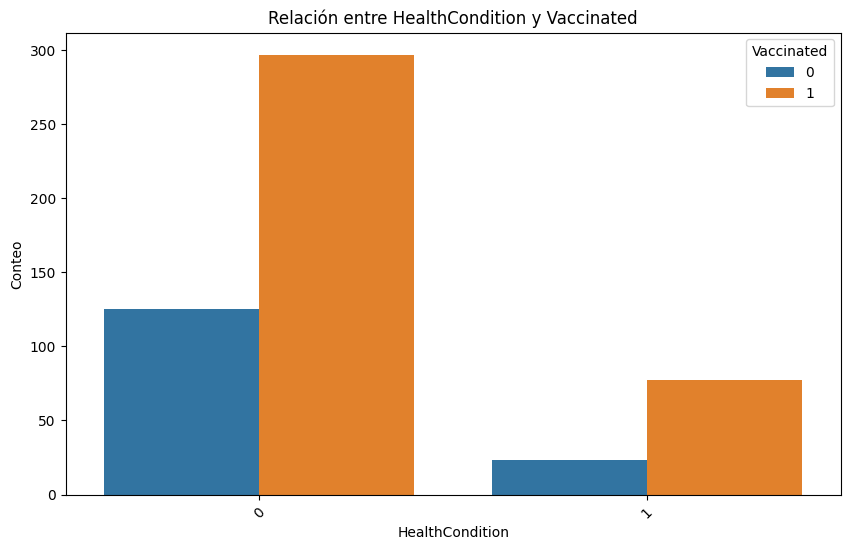

Respuesta Cat:


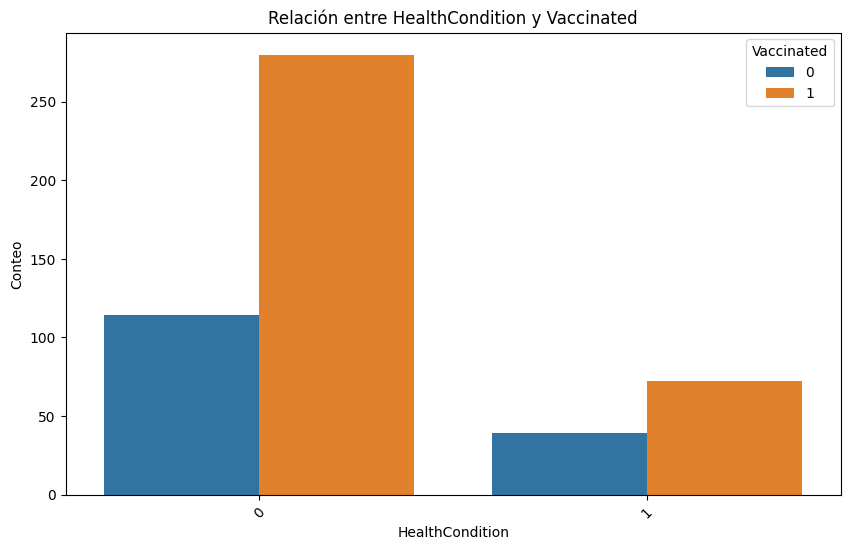

In [60]:
tricategorical_analysis(df_adopciones, "PetType", ["Vaccinated", "HealthCondition"])

In [61]:
tabla_contingencia = pd.crosstab(df_adopciones["Vaccinated"], df_adopciones["HealthCondition"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2, "\n")
print("P-Value:", p, "\n")
print("Grados de Libertad:", dof, "\n")
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 1.0349961171510558 

P-Value: 0.3089881051838054 

Grados de Libertad: 1 

Tabla de Frecuencias Esperadas:
 [[ 482.2122571  117.7877429]
 [1130.7877429  276.2122571]]


Igual que en las variables anteriores, se confirma independencia de las variables. Confirmado por p-value

##### Todas las variables categóricas son independientes entre sí. Variables correctas para la realización de los modelos

***

### Correlación de variables numéricas con la target gráficamente

In [20]:
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind

Hipótesis H0 -> No hay diferencia estadística significativa entre las medianas de los valores.

Hipótesis H1 -> Hay confianza estadística en que las medianas de cada grupo son diferentes para cada valor y hay relación entre los valores de la categórica y los de la numérica.

Para todas las variables!!!

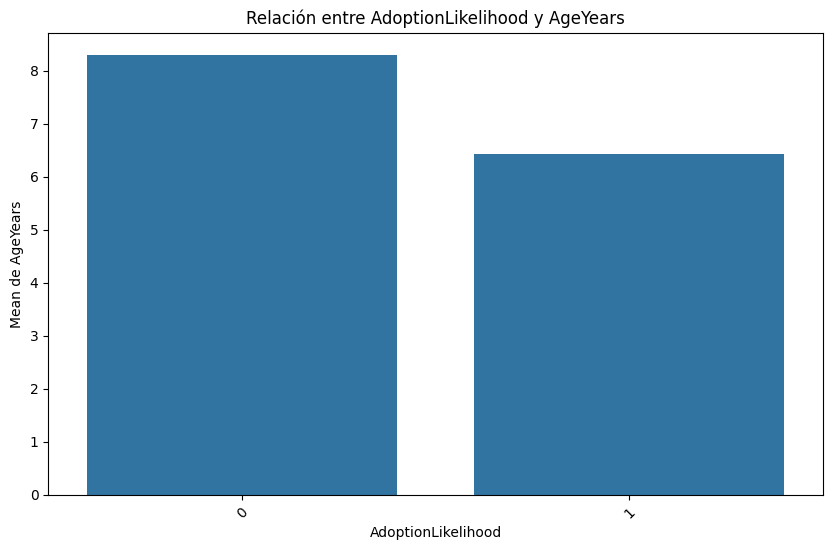

In [21]:
plot_categorical_numerical_relationship(df_adopciones, "AdoptionLikelihood", "AgeYears")

In [22]:
grupo_a = df_adopciones.loc[df_adopciones.AdoptionLikelihood == 1]["AgeYears"]
grupo_b = df_adopciones.loc[df_adopciones.AdoptionLikelihood == 0]["AgeYears"]

In [23]:
u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

Estadístico U: 335974.5
Valor p: 7.054675399822282e-19


p-value <<<<< 0.05, se acepta H1 --> Confianza estadística, relación entre los valores de la variable categórica y la numérica

***

In [24]:
t_stat, p_value = ttest_ind(grupo_a, grupo_b, equal_var=False)  
print(t_stat, p_value)

-8.776224393593827 6.033987482835166e-18


p-value <<<< 0.05 -> La media de AgeYears es distinta entre adoptados y no adoptados

***

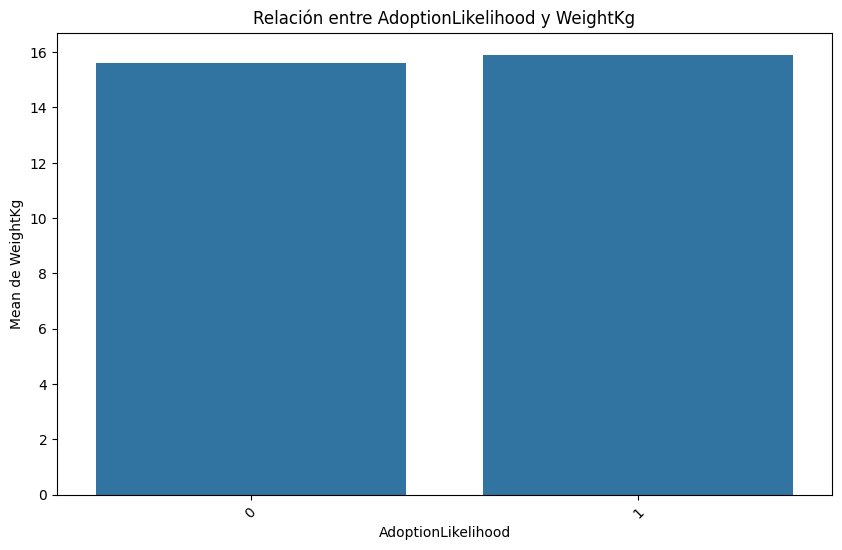

In [25]:
plot_categorical_numerical_relationship(df_adopciones, "AdoptionLikelihood", "WeightKg")

In [26]:
grupo_a = df_adopciones.loc[df_adopciones.AdoptionLikelihood == 1]["WeightKg"]
grupo_b = df_adopciones.loc[df_adopciones.AdoptionLikelihood == 0]["WeightKg"]

In [27]:
u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

Estadístico U: 454069.0
Valor p: 0.41667368078797873


p-value >>>>> 0.05, se acepta H0 --> No hay diferencia estadística, sin relación entre los valores de la variable categórica y la numérica

***

In [28]:
t_stat, p_value = ttest_ind(grupo_a, grupo_b, equal_var=False)  
print(t_stat, p_value)

0.781206545336303 0.43482592227203515


p-value >>>>> 0.05 -> La media de WeightKg no es distinta entre adoptados y no adoptados

***

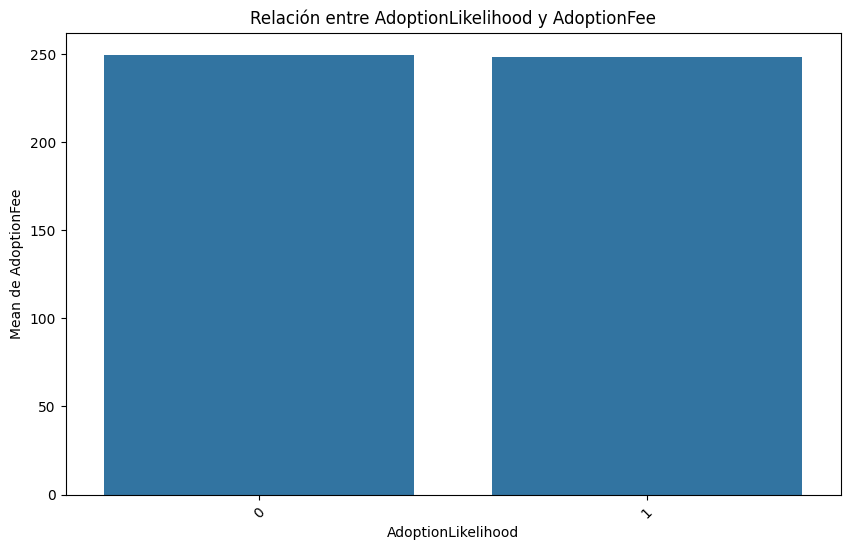

In [29]:
plot_categorical_numerical_relationship(df_adopciones, "AdoptionLikelihood", "AdoptionFee")

In [30]:
grupo_a = df_adopciones.loc[df_adopciones.AdoptionLikelihood == 1]["AdoptionFee"]
grupo_b = df_adopciones.loc[df_adopciones.AdoptionLikelihood == 0]["AdoptionFee"]

In [31]:
u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

Estadístico U: 441599.0
Valor p: 0.8332729857889424


p-value >>>>> 0.05, se acepta H0 --> No hay diferencia estadística, sin relación entre los valores de la variable categórica y la numérica

***

In [32]:
t_stat, p_value = ttest_ind(grupo_a, grupo_b, equal_var=False)  
print(t_stat, p_value)

-0.2490086666228909 0.8033918523861475


p-value >>>>> 0.05 -> La media de AdoptionFee no es distinta entre adoptados y no adoptados

***

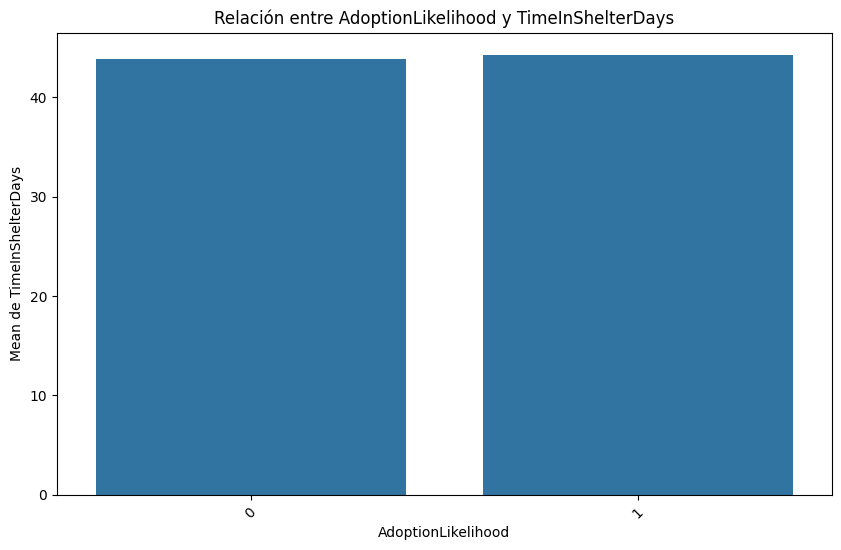

In [33]:
plot_categorical_numerical_relationship(df_adopciones, "AdoptionLikelihood", "TimeInShelterDays")

In [34]:
grupo_a = df_adopciones.loc[df_adopciones.AdoptionLikelihood == 1]["TimeInShelterDays"]
grupo_b = df_adopciones.loc[df_adopciones.AdoptionLikelihood == 0]["TimeInShelterDays"]

In [35]:
u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

Estadístico U: 449345.5
Valor p: 0.6709720558934993


p-value >>>>> 0.05, se acepta H0 --> No hay diferencia estadística, sin relación entre los valores de la variable categórica y la numérica

***

In [36]:
t_stat, p_value = ttest_ind(grupo_a, grupo_b, equal_var=False)  
print(t_stat, p_value)

0.39807370239842904 0.6906404879616224


p-value >>>>> 0.05 -> La media de AdoptionFee no es distinta entre adoptados y no adoptados

***

##### Numérica que permanece -> AgeYears

### Correlación entre variables numéricas (colinealidad)

In [37]:
numericas = ["WeightKg", "TimeInShelterDays", "AdoptionFee", "AgeYears"]

In [38]:
df_adop_num = df_adopciones[numericas]

In [39]:
corr = df_adop_num.corr()

In [40]:
corr

,WeightKg,TimeInShelterDays,AdoptionFee,AgeYears
WeightKg,1.000000,-0.000980,-0.002367,-0.029177
TimeInShelterDays,-0.000980,1.000000,-0.007104,0.036840
AdoptionFee,-0.002367,-0.007104,1.000000,-0.038140
AgeYears,-0.029177,0.036840,-0.038140,1.000000


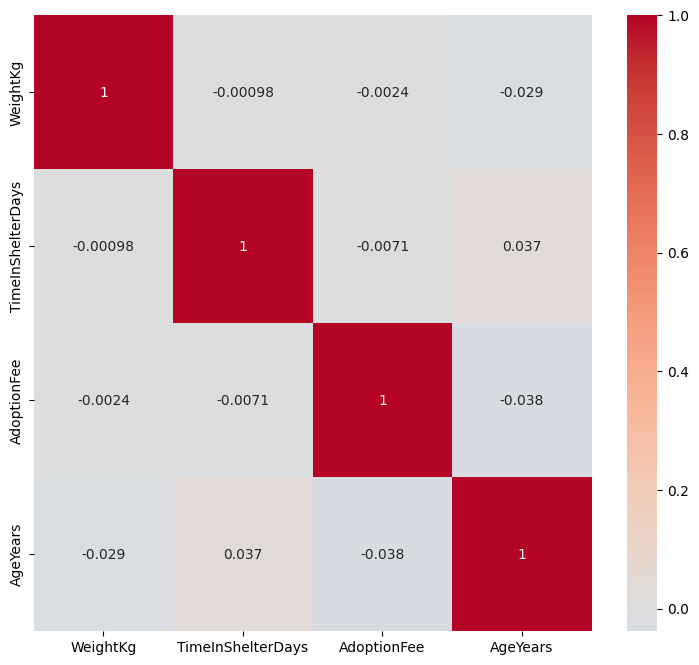

In [44]:
plt.figure(figsize = (9,8))
sns.heatmap(corr, annot = True, cmap = "coolwarm", center = 0)
plt.show()

##### La matriz de correlación entre las variables numéricas indica que no hay correlación entre ellas. Ninguna ce las correlaciones se aproxima al 1 ni al -1, por lo que se puede determinar que las variables numéricas son independientes entre ellas, por lo que son ideales para la elaboración de un modelo.